In [86]:
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_core.runnables import Runnable
from typing import Literal
from collections.abc import Sequence

In [72]:
from dotenv import load_dotenv
load_dotenv()

True

Graph 1
==========

In [73]:
class State(TypedDict):
    messages: Sequence[BaseMessage]

state = State(messages=[HumanMessage("Can You tell me about blackhole ?")])

state['messages'][0].pretty_print()

================================ Human Message =================================

Can You tell me about blackhole ?


Define Nodes

In [74]:
chat = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    #max_output_tokens=1000,
    temperature=0,
    seed=42
)

#response = chat.invoke(state['messages'])

#response.pretty_print()

In [75]:
def chatbot(state:State)-> State:
    print("\n--------------> Entering Chatbot:")
    response = chat.invoke(state['messages'])
    response.pretty_print()
    return State(messages = [response])

Define The Graph

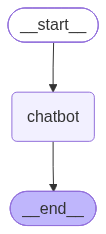

In [76]:
graph = StateGraph(State)


graph.add_node("chatbot", chatbot)

graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)


graph_complied = graph.compile()
graph_complied


In [77]:
#isinstance(graph_complied, Runnable), isinstance(graph, Runnable)

Test the Graph

In [79]:
graph_complied.invoke(state)


--------------> Entering Chatbot:


c:\Users\ANIK CHOWDHURY\Desktop\AI_Updated\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


================================== Ai Message ==================================

[{'type': 'text', 'text': 'A **black hole** is one of the most fascinating, mysterious, and extreme objects in the universe. \n\nAt its simplest, a black hole is a region in space where **gravity is so strong that nothing—not even light—can escape from it.** Because light cannot escape, black holes are invisible to the naked eye, which is why they are called "black" holes.\n\nHere is a breakdown of how they work, how they are formed, and the mind-bending physics surrounding them.\n\n---\n\n### 1. Anatomy of a Black Hole\nTo understand a black hole, it helps to know its key parts:\n\n*   **The Singularity:** This is the very center of the black hole. It is a point where a massive amount of matter is crushed into an infinitely small space, resulting in infinite density. At this point, our current understanding of physics (Einstein\'s general relativity) breaks down.\n*   **The Event Horizon:** This is the "

{'messages': [AIMessage(content=[{'type': 'text', 'text': 'A **black hole** is one of the most fascinating, mysterious, and extreme objects in the universe. \n\nAt its simplest, a black hole is a region in space where **gravity is so strong that nothing—not even light—can escape from it.** Because light cannot escape, black holes are invisible to the naked eye, which is why they are called "black" holes.\n\nHere is a breakdown of how they work, how they are formed, and the mind-bending physics surrounding them.\n\n---\n\n### 1. Anatomy of a Black Hole\nTo understand a black hole, it helps to know its key parts:\n\n*   **The Singularity:** This is the very center of the black hole. It is a point where a massive amount of matter is crushed into an infinitely small space, resulting in infinite density. At this point, our current understanding of physics (Einstein\'s general relativity) breaks down.\n*   **The Event Horizon:** This is the "point of no return." It is the invisible boundary 

Graph 2
====================

In [80]:
class State(TypedDict):
    messages: Sequence[BaseMessage]

In [ ]:
def ask(state:State)-> State:
    print("\n--------------> Entering Ask Question:")
    print("What is the Question?")
    return State(messages = [HumanMessage(input())])

ask(State(messages=[]))

In [82]:
chat = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    #max_output_tokens=1000,
    temperature=0,
    seed=42
)

In [83]:
def chatbot(state:State)-> State:
    print("\n--------------> Entering Chatbot:")
    response = chat.invoke(state['messages'])
    response.pretty_print()
    return State(messages = [response])

In [84]:
def ask_another(state:State)-> State:
    print("\n--------------> Entering ask another:")
    print("You want to ask another Question (Yes/No)")
    return State(messages = [HumanMessage(input())])

ask_another(State(messages=[]))


--------------> Entering ask another:
You want to ask another Question (Yes/No)


{'messages': [HumanMessage(content='yes', additional_kwargs={}, response_metadata={})]}

In [87]:
def routing(state:State)-> Literal["ask", "__end__"]:
    if state["messages"][0].content == "yes":
        return "ask"
    else:
        return "__end__"

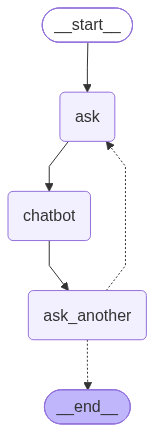

In [90]:
graph = StateGraph(State)

graph.add_node('ask', ask)
graph.add_node('chatbot', chatbot)
graph.add_node('ask_another', ask_another)

graph.add_edge(START, "ask")
graph.add_edge("ask", "chatbot")
graph.add_edge("chatbot", "ask_another")
graph.add_conditional_edges(source='ask_another', path = routing)

graph_complied = graph.compile()

graph_complied

In [91]:
graph_complied.invoke(State(messages=[]))


--------------> Entering Ask Question:
What is the Question?

--------------> Entering Chatbot:


c:\Users\ANIK CHOWDHURY\Desktop\AI_Updated\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


================================== Ai Message ==================================

[{'type': 'text', 'text': '**Astrology** is a symbolic system and ancient belief that the positions, movements, and alignments of celestial bodies—such as the Sun, Moon, planets, and stars—influence human behavior, personality, relationships, and earthly events.\n\nThe foundational principle of astrology is often summarized by the ancient phrase: *"As above, so below."* This implies a meaningful correlation between macrocosmic events in space and microcosmic experiences on Earth.\n\nHere is a breakdown of how astrology works, its main components, its history, and its distinction from science.\n\n---\n\n### 1. The Core Components of Astrology\n\nWhile many people only know their "Sun sign" (e.g., "I\'m a Taurus"), professional astrology uses a complex system based on a **Natal Chart** (or Horoscope). A natal chart is a map of the sky at the exact time, date, and location of a person\'s birth.\n\nA natal ch

c:\Users\ANIK CHOWDHURY\Desktop\AI_Updated\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


================================== Ai Message ==================================

[{'type': 'text', 'text': 'Yes, there is a **deep historical relationship** between astrology and astronomy, but today they are fundamentally different disciplines. \n\nIn short: **Astronomy is a science**, while **astrology is a belief system (or pseudoscience)**.\n\nHere is a breakdown of how they are related, how they split, and where they stand today.\n\n---\n\n### 1. The Historical Connection (They Were Once the Same)\nFor thousands of years, astrology and astronomy were intertwined. You could not have one without the other.\n* **Shared Beginnings:** Ancient civilizations (such as the Babylonians, Greeks, Egyptians, and Mayans) looked at the night sky to track seasons and crop cycles. To do this, they mapped the stars (**astronomy**). At the same time, they believed these sky patterns were messages from gods or indicators of human destiny (**astrology**).\n* **Famous Historical Figures:** Many of his

{'messages': [HumanMessage(content='no', additional_kwargs={}, response_metadata={})]}

Graph 3
=========